# Experiment 1: Joint specialization through architectural inductive bias

Suppose we want a model where one part specializes on task A and another part specializes on task B, but only 25% of samples are labeled with their task identity. 

One approach is to first train a classifier to extend these labels, then train two separate models and use the classifier to route inputs to the appropriate model. 

An alternative — demonstrated here — is to train everything jointly: two specialist models and a gate that routes between them, using a single classification loss. This illustrates a principle similar to that of absorption from Gradient Routing (https://arxiv.org/abs/2410.04332) and SGTM (https://alignment.anthropic.com/2025/selective-gradient-masking/).

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

## Dataset

Standard MNIST, split into two tasks: recognizing digits 0–4 is **task A** (`label=0`) and recognizing digits 5–9 is **task B** (`label=1`). Each sample is independently marked as *known* with 25% probability — meaning its task label is available during training. The remaining 75% are *unknown*.

In [2]:
class SimpleMNIST(Dataset):
    def __init__(self, train, prob_known=0.25, root="data", seed=42):
        self.base = datasets.MNIST(
            root=root, train=train, download=True, transform=transforms.ToTensor()
        )
        rng = np.random.RandomState(seed)
        self.is_known = rng.rand(len(self.base)) < prob_known
        self.labels = (self.base.targets.numpy() >= 5).astype(int)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, digit = self.base[idx]
        return {
            "image": image,
            "label": int(self.labels[idx]),
            "digit": digit,
            "is_known": bool(self.is_known[idx]),
        }


PROB_KNOWN = 0.25
train_ds = SimpleMNIST(train=True, prob_known=PROB_KNOWN, seed=42)
test_ds = SimpleMNIST(train=False, prob_known=PROB_KNOWN, seed=43)

print(
    f"Train: {len(train_ds):,} total, {train_ds.is_known.sum():,} known ({train_ds.is_known.mean():.1%})"
)
print(
    f"Test:  {len(test_ds):,} total, {test_ds.is_known.sum():,} known ({test_ds.is_known.mean():.1%})"
)

Train: 60,000 total, 14,984 known (25.0%)
Test:  10,000 total, 2,410 known (24.1%)


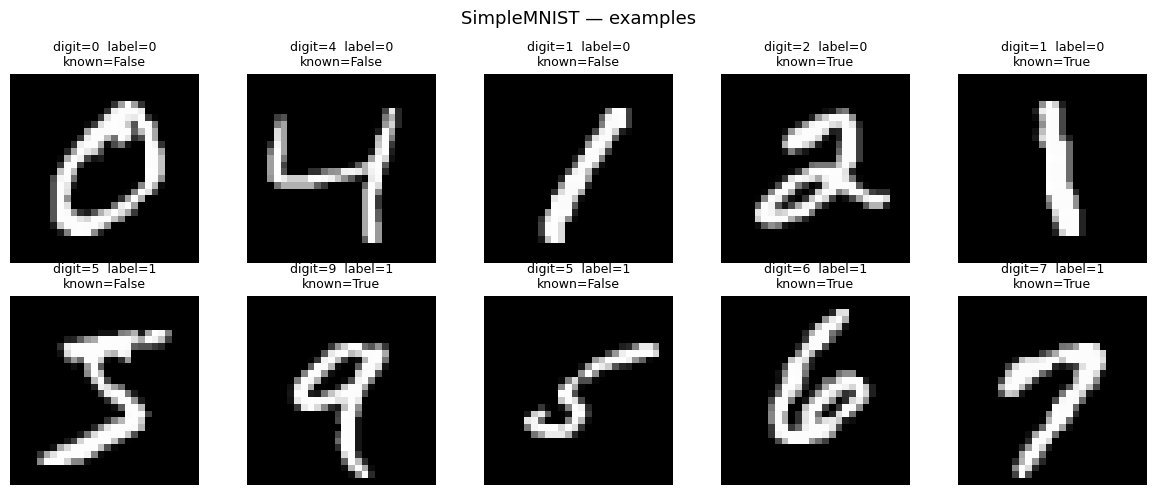

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
shown = [0, 0]

for idx in range(len(train_ds)):
    item = train_ds[idx]
    row = item["label"]
    if shown[row] < 5:
        ax = axes[row, shown[row]]
        ax.imshow(item["image"].squeeze(), cmap="gray")
        ax.set_title(
            f"digit={item['digit']}  label={row}\nknown={item['is_known']}", fontsize=9
        )
        ax.axis("off")
        shown[row] += 1
    if all(s >= 5 for s in shown):
        break

axes[0, 0].set_ylabel("Low (0\u20134)", fontsize=11)
axes[1, 0].set_ylabel("High (5\u20139)", fontsize=11)
fig.suptitle("SimpleMNIST \u2014 examples", fontsize=13)
fig.tight_layout()
plt.show()

## Gated system architecture

The system has three components: two binary classifiers (`model_safe` and `model_unsafe`) and a `Gate`. The system's output is a soft mixture of the two classifiers' softmax predictions of the input image's class, weighted by the gate:

```
prediction = (1 - gate) * softmax(safe_logits) + gate * softmax(unsafe_logits)
```

The intent is for `model_safe` to specialize on task A and `model_unsafe` on task B, with the gate learning to output values near 0 for task A inputs and near 1 for task B inputs.

In [4]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        return self.net(x)


class Gate(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 1),
        )

    def forward(self, x):
        return torch.sigmoid(self.net(x))


class GatedSystem(nn.Module):
    def __init__(self, gate, model_safe, model_unsafe):
        super().__init__()
        self.gate = gate
        self.model_safe = model_safe
        self.model_unsafe = model_unsafe

    def forward(self, images, is_known=None, binary_label=None):
        safe_logits = self.model_safe(images)
        unsafe_logits = self.model_unsafe(images)
        gate = self.gate(images)

        g = gate
        if self.training and is_known is not None and binary_label is not None:
            known = is_known.to(device=images.device, dtype=gate.dtype).unsqueeze(1)
            target = binary_label.to(device=images.device, dtype=gate.dtype).unsqueeze(
                1
            )
            g = torch.where(known.bool(), target, gate)

        p_safe = torch.softmax(safe_logits, dim=-1)
        p_unsafe = torch.softmax(unsafe_logits, dim=-1)

        return {
            "prediction": (1 - g) * p_safe + g * p_unsafe,
            "safe_logits": safe_logits,
            "unsafe_logits": unsafe_logits,
            "gate": gate,
        }

## Joint training

The full system — gate and both classifiers — is trained from scratch with a single classification loss. On **known** samples, we teacher-force the gate: task A samples are routed entirely through `model_safe` and task B samples entirely through `model_unsafe`. On **unknown** samples (75% of the data), the learned gate value determines the soft routing.

This teacher forcing creates an inductive bias: `model_safe` receives concentrated task A gradients and becomes better at task A, while `model_unsafe` becomes better at task B. Thanks to this, the gate learns to activate the correct specialist even on unlabeled data and even without an explicit gate loss. Note that here, due to teacher forcing, the gate gets no gradients on labeled examples; in production environments, we'd have a separate binary classification loss that we'd apply to the gate, to fully utilize the labels even if we do teacher forcing.

The evaluation below confirms this: forcing `gate=0` (using only `model_safe`) achieves perfect accuracy on task A and zero on task B, and vice versa for `gate=1`. The gate value plot in the next cell shows the average gate output for each task diverging during training as the specialization emerges.

In [5]:
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

system = GatedSystem(Gate(), Classifier(), Classifier()).to(device)
optimizer = torch.optim.Adam(system.parameters(), lr=1e-3)

gate_log = {"step": [], "low": [], "high": []}

EPOCHS = 2
step = 0
for epoch in range(1, EPOCHS + 1):
    system.train()
    total_loss, n = 0.0, 0
    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        out = system(images, is_known=batch["is_known"], binary_label=batch["label"])
        loss = nn.functional.nll_loss(
            torch.log(out["prediction"].clamp(min=1e-8)), labels
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(images)
        n += len(images)

        with torch.no_grad():
            g = out["gate"].squeeze(1)
            is_high = labels.bool()
            gate_log["step"].append(step)
            gate_log["low"].append(g[~is_high].mean().item())
            gate_log["high"].append(g[is_high].mean().item())
        step += 1

    print(f"epoch {epoch}/{EPOCHS}  loss={total_loss / n:.4f}")


def evaluate(system, loader, force_gate=None):
    system.eval()
    counts = {"low (0-4)": [0, 0], "high (5-9)": [0, 0]}
    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            is_high = labels.bool()
            out = system(images)

            if force_gate is not None:
                g = torch.full_like(out["gate"], force_gate)
                p_safe = torch.softmax(out["safe_logits"], dim=-1)
                p_unsafe = torch.softmax(out["unsafe_logits"], dim=-1)
                preds = ((1 - g) * p_safe + g * p_unsafe).argmax(dim=-1)
            else:
                preds = out["prediction"].argmax(dim=-1)

            eq = preds.eq(labels)
            counts["low (0-4)"][0] += eq[~is_high].sum().item()
            counts["low (0-4)"][1] += (~is_high).sum().item()
            counts["high (5-9)"][0] += eq[is_high].sum().item()
            counts["high (5-9)"][1] += is_high.sum().item()

    accs = {k: c / t if t else float("nan") for k, (c, t) in counts.items()}
    accs["all"] = sum(v[0] for v in counts.values()) / sum(
        v[1] for v in counts.values()
    )
    return accs


for name, fg in [
    ("system (gate learned)", None),
    ("safe model only (gate=0)", 0.0),
    ("unsafe model only (gate=1)", 1.0),
]:
    print(f"\n--- {name} ---")
    for k, v in evaluate(system, test_loader, force_gate=fg).items():
        print(f"  {k:12s} {v:.4f}")

gate_correct, gate_total = 0, 0
with torch.no_grad():
    for batch in test_loader:
        preds = system.gate(batch["image"].to(device)).squeeze(1) >= 0.5
        gate_correct += (
            preds.eq(batch["label"].to(device, dtype=torch.bool)).sum().item()
        )
        gate_total += len(batch["image"])
print(f"\n--- system gate accuracy: {gate_correct / gate_total:.4f} ---")

epoch 1/2  loss=0.2199
epoch 2/2  loss=0.1258

--- system (gate learned) ---
  low (0-4)    0.9346
  high (5-9)   0.9523
  all          0.9432

--- safe model only (gate=0) ---
  low (0-4)    1.0000
  high (5-9)   0.0000
  all          0.5139

--- unsafe model only (gate=1) ---
  low (0-4)    0.0000
  high (5-9)   1.0000
  all          0.4861

--- system gate accuracy: 0.9432 ---


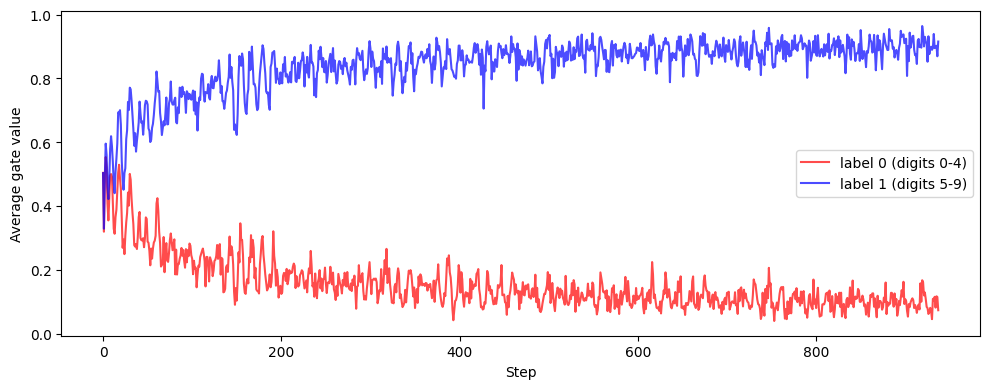

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(
    gate_log["step"],
    gate_log["low"],
    color="red",
    label="label 0 (digits 0-4)",
    alpha=0.7,
)
plt.plot(
    gate_log["step"],
    gate_log["high"],
    color="blue",
    label="label 1 (digits 5-9)",
    alpha=0.7,
)
plt.xlabel("Step")
plt.ylabel("Average gate value")
plt.legend()
plt.tight_layout()
plt.show()